# Retail Customer Intelligence & Retention Analytics

**Dataset:** UCI Online Retail (541,909 transaction records, Dec 2010 - Sep 2011)
**Objective:** Identify customer segments, predict churn, and deliver actionable business recommendations.

## Notebook Outline
1. Data Loading & Cleaning
2. Exploratory Data Analysis (EDA)
3. Customer Feature Engineering
4. RFM Segmentation
5. K-Means Clustering
6. Cohort Retention Analysis
7. Temporal Churn Prediction
8. Business Recommendations

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

## 1. Data Loading & Cleaning

In [33]:
from pathlib import Path
import sys

ROOT = Path().resolve()
if not (ROOT / 'src').exists():
    ROOT = ROOT.parent

if str(ROOT) not in sys.path:
    sys.path.insert(0,str(ROOT))


RAW = ROOT / 'data' / 'raw' / 'online-retail' / 'Online Retail.xlsx'
df_raw = pd.read_excel(RAW)
print(f'Raw shape: {df_raw.shape}')
print(f'Columns: {list(df_raw.columns)}')
df_raw.head()

Raw shape: (541909, 8)
Columns: ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [9]:
df_raw.info()
print(f"\nMissing values:\n{df_raw.isnull().sum()}")

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 40.0+ MB

Missing values:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


In [5]:
df = df_raw.copy()
df.columns = [c.strip() for c in df.columns]
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['InvoiceNo'] = df['InvoiceNo'].astype(str)

n_before = len(df)
df = df.drop_duplicates()
n_dupes = n_before - len(df)
df = df[df['CustomerID'].notna()]
df = df[df['UnitPrice'] > 0]
df = df[df['Quantity'] > 0]
df = df[~df['InvoiceNo'].str.upper().str.startswith('C')]
df['Revenue'] = df['Quantity'] * df['UnitPrice']

print(f'Raw records:        {n_before:,}')
print(f'Duplicates removed: {n_dupes:,}')
print(f'Clean records:      {len(df):,}')
print(f'Unique customers:   {df.CustomerID.nunique():,}')
print(f'Unique invoices:    {df.InvoiceNo.nunique():,}')
print(f'Total revenue:      £{df.Revenue.sum():,.2f}')

Raw records:        541,909
Duplicates removed: 5,268
Clean records:      392,692
Unique customers:   4,338
Unique invoices:    18,532
Total revenue:      £8,887,208.89


## 2. Exploratory Data Analysis

Key questions: What does the data look like? Which products, countries, and time periods drive revenue? Is revenue concentrated among a few customers?

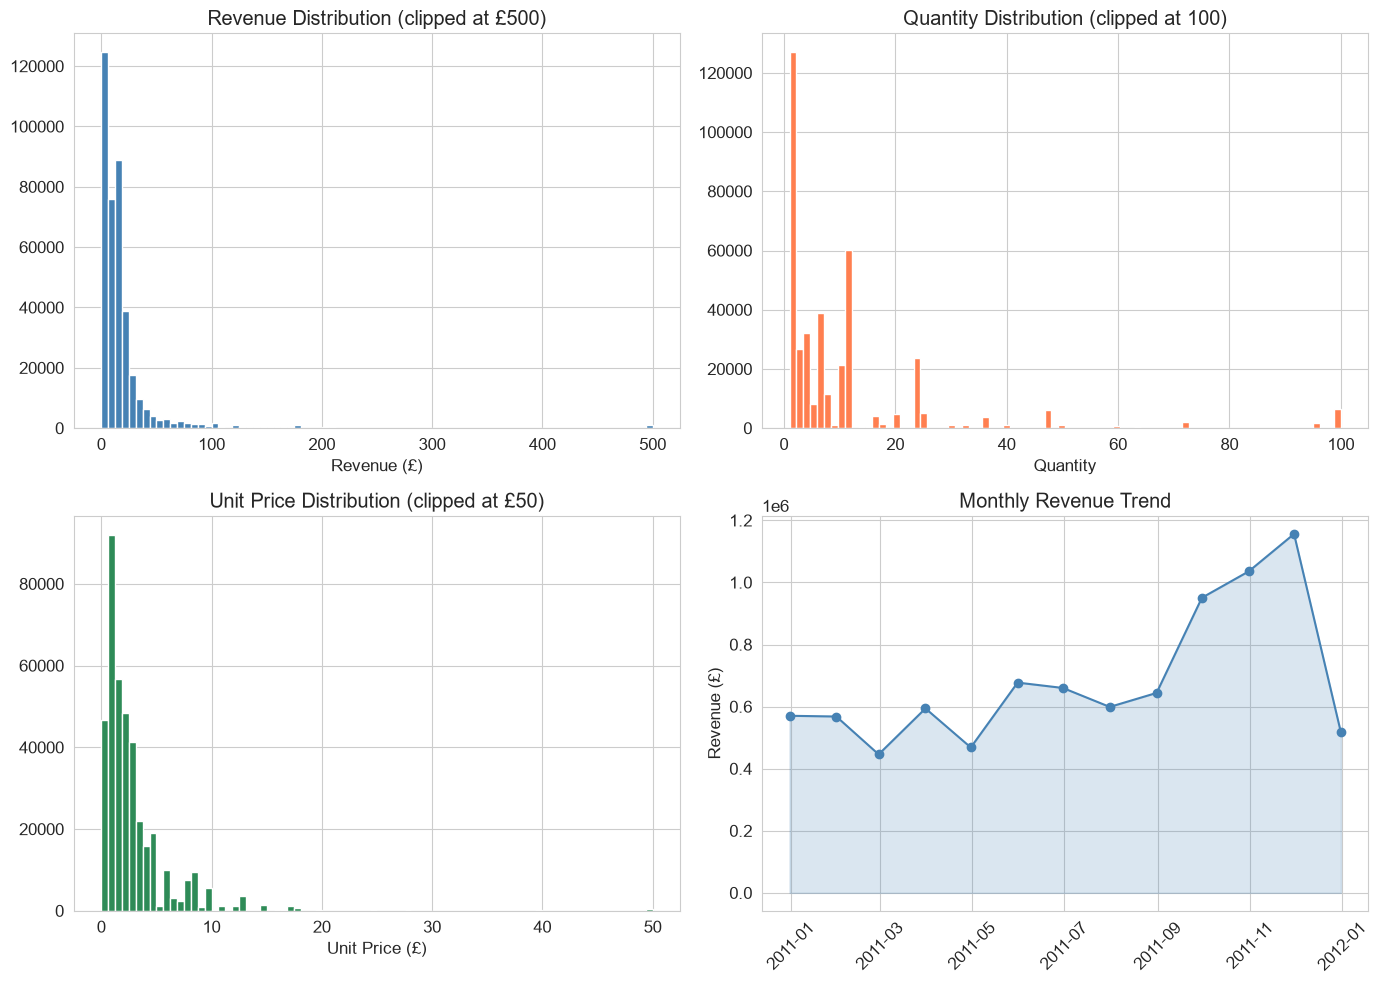

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].hist(df['Revenue'].clip(upper=500), bins=80, edgecolor='white', color='steelblue')
axes[0, 0].set_title('Revenue Distribution (clipped at £500)')
axes[0, 0].set_xlabel('Revenue (£)')

axes[0, 1].hist(df['Quantity'].clip(upper=100), bins=80, edgecolor='white', color='coral')
axes[0, 1].set_title('Quantity Distribution (clipped at 100)')
axes[0, 1].set_xlabel('Quantity')

axes[1, 0].hist(df['UnitPrice'].clip(upper=50), bins=80, edgecolor='white', color='seagreen')
axes[1, 0].set_title('Unit Price Distribution (clipped at £50)')
axes[1, 0].set_xlabel('Unit Price (£)')

monthly = df.set_index('InvoiceDate').resample('ME')['Revenue'].sum()
axes[1, 1].plot(monthly.index, monthly.values, marker='o', color='steelblue')
axes[1, 1].fill_between(monthly.index, monthly.values, alpha=0.2, color='steelblue')
axes[1, 1].set_title('Monthly Revenue Trend')
axes[1, 1].set_ylabel('Revenue (£)')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

>Revenue per line item is heavily right-skewed, with a long tail of high-value transactions

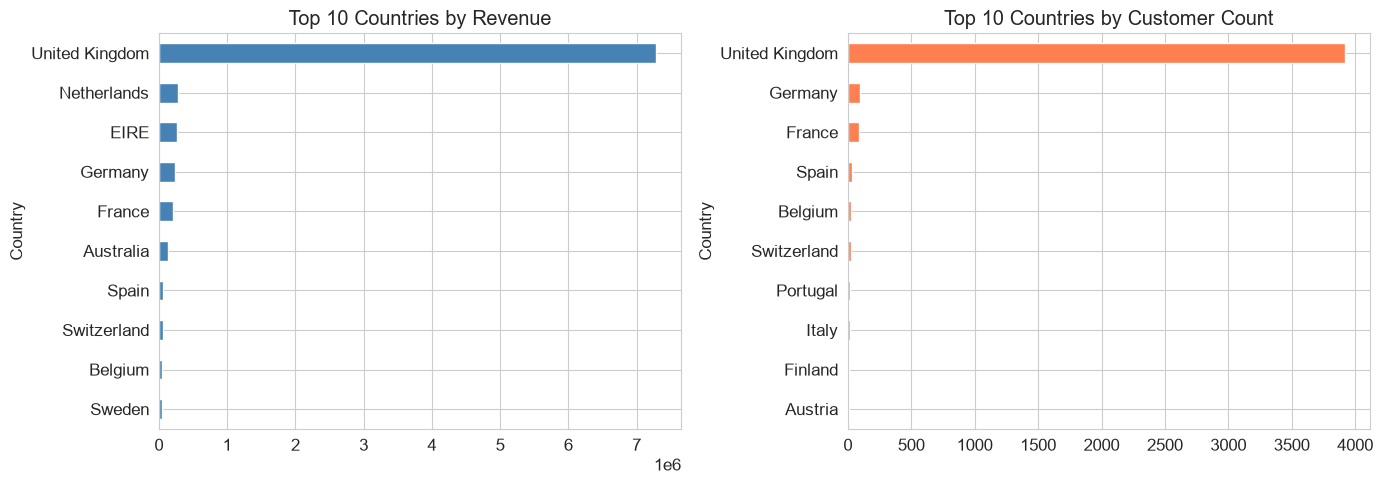

In [15]:
country_rev = df.groupby('Country')['Revenue'].sum().sort_values(ascending=False).head(10)
country_cust = df.groupby('Country')['CustomerID'].nunique().sort_values(ascending=False).head(10)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
country_rev.plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Top 10 Countries by Revenue')
axes[0].invert_yaxis()
country_cust.plot(kind='barh', ax=axes[1], color='coral')
axes[1].set_title('Top 10 Countries by Customer Count')
axes[1].invert_yaxis()
plt.tight_layout()
plt.show()

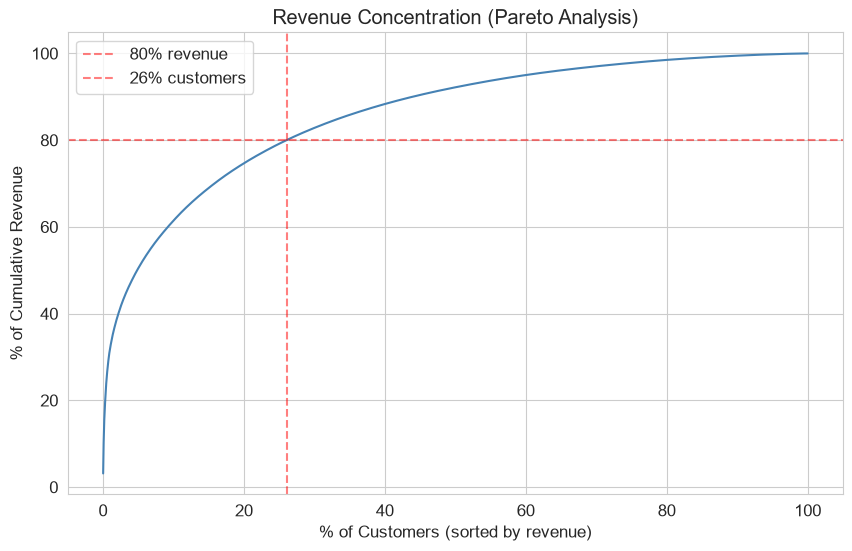

Top 26% of customers generate 80% of revenue


In [16]:
cust_rev = df.groupby('CustomerID')['Revenue'].sum().sort_values(ascending=False).reset_index()
cust_rev['cum_revenue'] = cust_rev['Revenue'].cumsum() / cust_rev['Revenue'].sum()
cust_rev['pct_customers'] = np.arange(1, len(cust_rev) + 1) / len(cust_rev)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(cust_rev['pct_customers'] * 100, cust_rev['cum_revenue'] * 100, color='steelblue')
ax.axhline(80, color='red', linestyle='--', alpha=0.5, label='80% revenue')
pct_at_80 = cust_rev[cust_rev['cum_revenue'] >= 0.8]['pct_customers'].iloc[0] * 100
ax.axvline(pct_at_80, color='red', linestyle='--', alpha=0.5, label=f'{pct_at_80:.0f}% customers')
ax.set_xlabel('% of Customers (sorted by revenue)')
ax.set_ylabel('% of Cumulative Revenue')
ax.set_title('Revenue Concentration (Pareto Analysis)')
ax.legend()
plt.show()
print(f'Top {pct_at_80:.0f}% of customers generate 80% of revenue')

In [17]:
# Top 20 products by revenue
top_products = df.groupby(['StockCode', 'Description'])['Revenue'].sum().reset_index()
top_products = top_products.sort_values('Revenue', ascending=False).head(20)
top_products[['Description', 'Revenue']].style.format({'Revenue': '£{:,.2f}'})

,Description,Revenue
2529,"PAPER CRAFT , LITTLE BIRDIE","£168,469.60"
1245,REGENCY CAKESTAND 3 TIER,"£142,264.75"
3576,WHITE HANGING HEART T-LIGHT HOLDER,"£100,392.10"
3569,JUMBO BAG RED RETROSPOT,"£85,040.54"
2027,MEDIUM CERAMIC TOP STORAGE JAR,"£81,416.73"
3896,POSTAGE,"£77,803.96"
2607,PARTY BUNTING,"£68,785.23"
2810,ASSORTED COLOUR BIRD ORNAMENT,"£56,413.03"
3894,Manual,"£53,419.93"
1933,RABBIT NIGHT LIGHT,"£51,251.24"


             Transactions    Revenue
InvoiceDate                         
2010-12-01            121   46192.49
2010-12-02            137   47197.57
2010-12-03             57   23876.63
2010-12-04              0       0.00
2010-12-05             87   31361.28
...                   ...        ...
2011-12-05            116   58081.09
2011-12-06            110   45989.66
2011-12-07            104   69230.60
2011-12-08            113   50395.96
2011-12-09             41  184329.66

[374 rows x 2 columns]


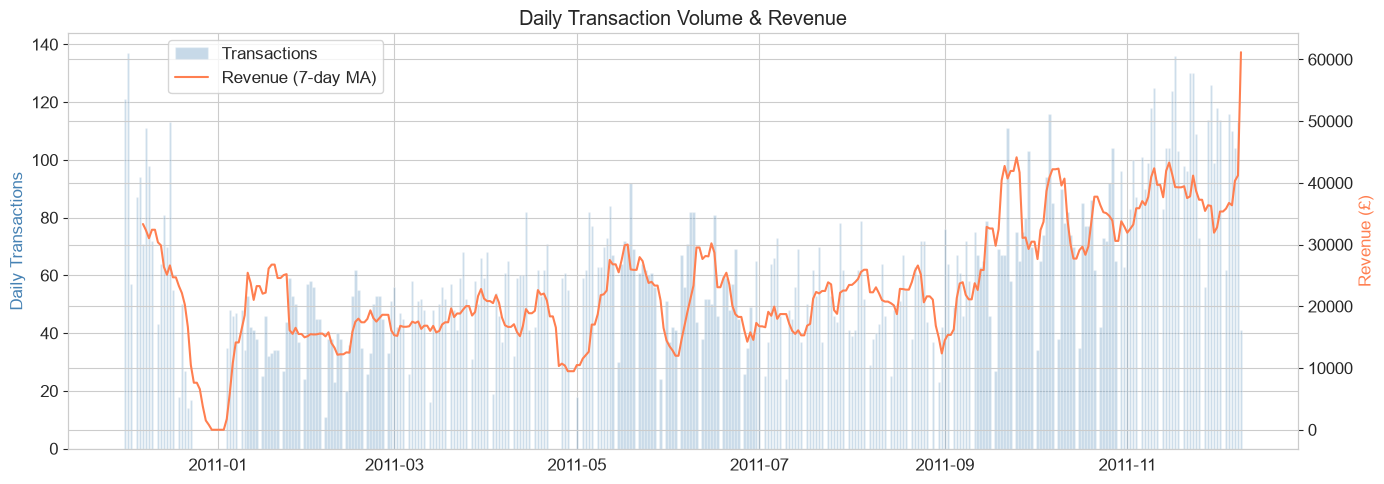

In [32]:
# Daily transaction volume over time
daily = df.set_index('InvoiceDate').resample('D').agg(
    Transactions=('InvoiceNo', 'nunique'),
    Revenue=('Revenue', 'sum')
)
print(daily)
fig, ax1 = plt.subplots(figsize=(14, 5))
ax1.bar(daily.index, daily['Transactions'], alpha=0.3, color='steelblue', label='Transactions')
ax1.set_ylabel('Daily Transactions', color='steelblue')

ax2 = ax1.twinx()
# 7 day moving avg
ax2.plot(daily.index, daily['Revenue'].rolling(7).mean(), color='coral', label='Revenue (7-day MA)')
ax2.set_ylabel('Revenue (£)', color='coral')
ax1.set_title('Daily Transaction Volume & Revenue')
fig.legend(loc='upper left', bbox_to_anchor=(0.12, 0.92))
plt.tight_layout()
plt.show()

## 3. Customer Feature Engineering

Building per-customer features from transaction-level data for downstream segmentation and modeling.

In [34]:
from src.features import customer_features
features = customer_features(df)
print(f'Customer features shape: {features.shape}')
features.head(10)

Customer features shape: (4338, 10)


,CustomerID,last_purchase,first_purchase,frequency,monetary,total_items,avg_order_value,recency,customer_lifetime_days,avg_days_between_orders
0,12346.0,2011-01-18 10:01:00,2011-01-18 10:01:00,1,77183.60,74215,77183.600000,326,0,0.000000
1,12347.0,2011-12-07 15:52:00,2010-12-07 14:57:00,7,4310.00,2458,615.714286,2,365,60.333333
2,12348.0,2011-09-25 13:13:00,2010-12-16 19:09:00,4,1797.24,2341,449.310000,75,282,94.000000
3,12349.0,2011-11-21 09:51:00,2011-11-21 09:51:00,1,1757.55,631,1757.550000,19,0,0.000000
4,12350.0,2011-02-02 16:01:00,2011-02-02 16:01:00,1,334.40,197,334.400000,310,0,0.000000
5,12352.0,2011-11-03 14:37:00,2011-02-16 12:33:00,8,2506.04,536,313.255000,36,260,36.857143
6,12353.0,2011-05-19 17:47:00,2011-05-19 17:47:00,1,89.00,20,89.000000,204,0,0.000000
7,12354.0,2011-04-21 13:11:00,2011-04-21 13:11:00,1,1079.40,530,1079.400000,232,0,0.000000
8,12355.0,2011-05-09 13:49:00,2011-05-09 13:49:00,1,459.40,240,459.400000,214,0,0.000000
9,12356.0,2011-11-17 08:40:00,2011-01-18 09:50:00,3,2811.43,1591,937.143333,23,302,151.000000


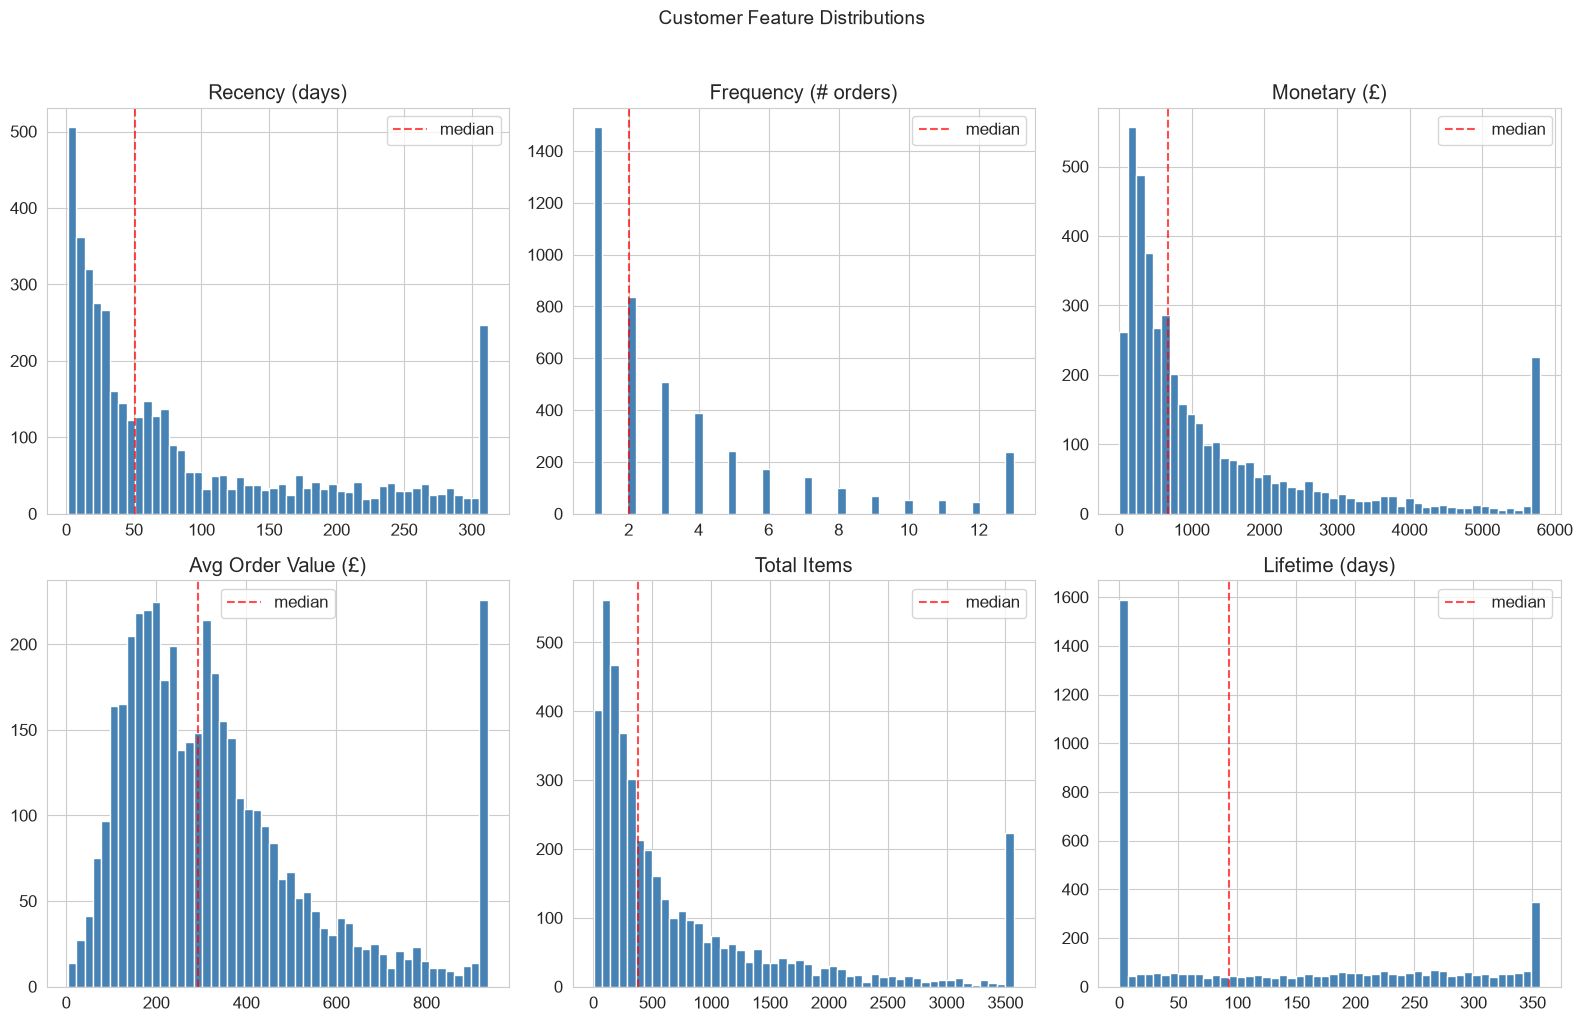

In [35]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
metrics = ['recency', 'frequency', 'monetary', 'avg_order_value', 'total_items', 'customer_lifetime_days']
titles = ['Recency (days)', 'Frequency (# orders)', 'Monetary (£)',
          'Avg Order Value (£)', 'Total Items', 'Lifetime (days)']

for i, (m, t) in enumerate(zip(metrics, titles)):
    ax = axes[i // 3, i % 3]
    data = features[m].clip(upper=features[m].quantile(0.95))
    ax.hist(data, bins=50, edgecolor='white', color='steelblue')
    ax.set_title(t)
    ax.axvline(features[m].median(), color='red', linestyle='--', alpha=0.7, label='median')
    ax.legend()

plt.suptitle('Customer Feature Distributions', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [36]:
features[metrics].describe().round(2)

,recency,frequency,monetary,avg_order_value,total_items,customer_lifetime_days
count,4338.00,4338.00,4338.00,4338.00,4338.00,4338.00
mean,92.54,4.27,2048.69,417.65,1187.64,130.45
std,100.01,7.70,8985.23,1796.51,5043.62,132.04
min,1.00,1.00,3.75,3.45,1.00,0.00
25%,18.00,1.00,306.48,177.87,159.00,0.00
50%,51.00,2.00,668.57,291.94,378.00,92.50
75%,142.00,5.00,1660.60,428.28,989.75,251.75
max,374.00,209.00,280206.02,84236.25,196915.00,373.00


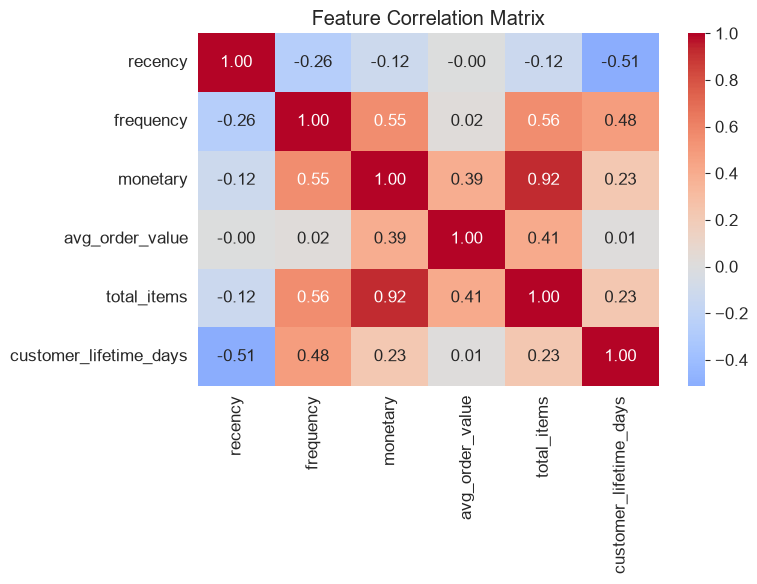

In [37]:
# Correlation heatmap
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(features[metrics].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

## 4. RFM Segmentation

Recency-Frequency-Monetary scoring classifies customers into actionable segments: Champions, Loyal, Potential Loyalists, Low Value, and At Risk.

In [39]:
from src.features import rfm_segment
rfm = rfm_segment(features)
print(f'Segment distribution:')
print(rfm['Segment'].value_counts().to_string())
rfm[['CustomerID', 'R', 'F', 'M', 'RFM_Score', 'Segment']].head(10)

Segment distribution:
Segment
At Risk/Lost          1905
Low Value              944
Loyal Customer         876
Potential Loyalist     613
Champion                 0


,CustomerID,R,F,M,RFM_Score,Segment
0,12346.0,1,1,5,7,At Risk/Lost
1,12347.0,5,5,5,15,Loyal Customer
2,12348.0,2,4,4,10,Low Value
3,12349.0,4,1,4,9,Low Value
4,12350.0,1,1,2,4,At Risk/Lost
5,12352.0,3,5,5,13,Loyal Customer
6,12353.0,1,1,1,3,At Risk/Lost
7,12354.0,1,1,4,6,At Risk/Lost
8,12355.0,1,1,2,4,At Risk/Lost
9,12356.0,4,3,5,12,Potential Loyalist


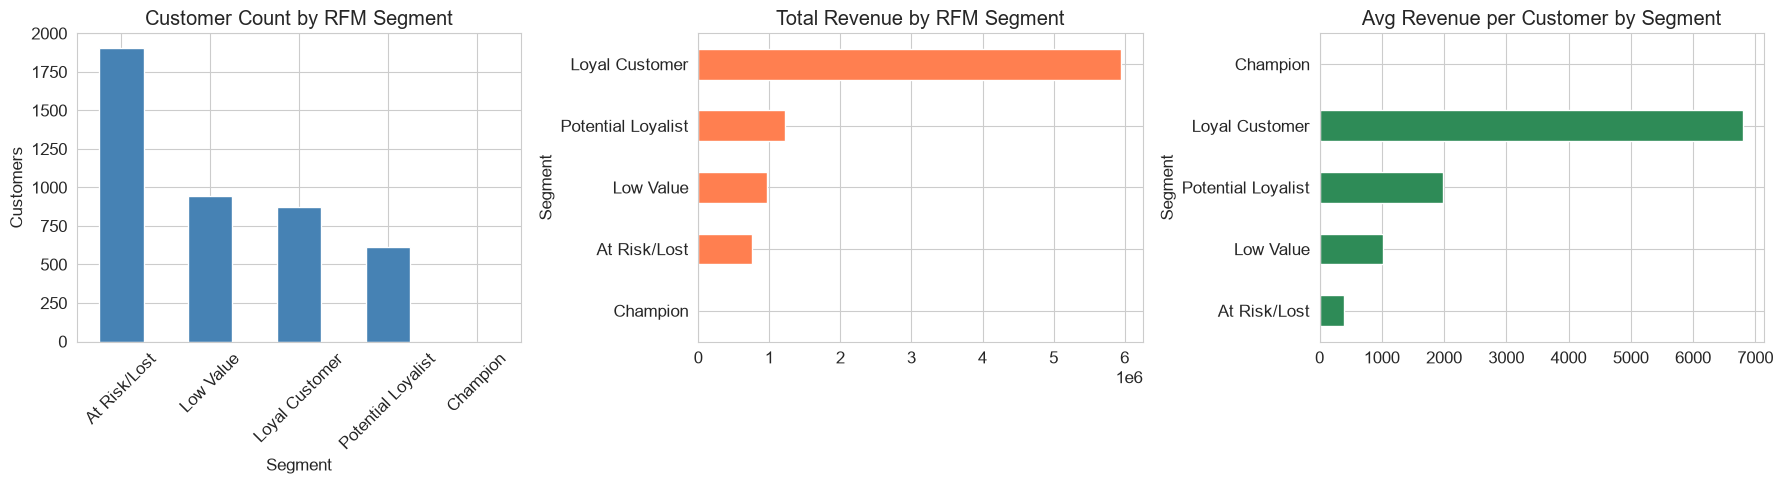

In [40]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

seg_counts = rfm['Segment'].value_counts()
seg_counts.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Customer Count by RFM Segment')
axes[0].set_ylabel('Customers')
axes[0].tick_params(axis='x', rotation=45)

seg_rev = rfm.groupby('Segment', observed=False)['monetary'].sum().sort_values(ascending=True)
seg_rev.plot(kind='barh', ax=axes[1], color='coral', edgecolor='white')
axes[1].set_title('Total Revenue by RFM Segment')

seg_avg = rfm.groupby('Segment', observed=False)['monetary'].mean().sort_values(ascending=True)
seg_avg.plot(kind='barh', ax=axes[2], color='seagreen', edgecolor='white')
axes[2].set_title('Avg Revenue per Customer by Segment')

plt.tight_layout()
plt.show()

In [41]:
seg_profile = rfm.groupby('Segment', observed=False).agg(
    Customers=('CustomerID', 'count'),
    Avg_Recency=('recency', 'mean'),
    Avg_Frequency=('frequency', 'mean'),
    Avg_Monetary=('monetary', 'mean'),
    Total_Revenue=('monetary', 'sum')
).round(2)
seg_profile['Pct_Revenue'] = (seg_profile['Total_Revenue'] / seg_profile['Total_Revenue'].sum() * 100).round(1)
seg_profile

,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary,Total_Revenue,Pct_Revenue
Segment,,,,,,
At Risk/Lost,1905,161.07,1.30,393.97,750518.44,8.4
Low Value,944,63.16,2.70,1021.96,964734.76,10.9
Potential Loyalist,613,37.29,4.64,1985.25,1216956.56,13.7
Loyal Customer,876,13.81,12.16,6797.94,5954999.13,67.0
Champion,0,NaN,NaN,NaN,0.00,0.0


## 5. K-Means Clustering

Unsupervised clustering on log-transformed, standardized features to discover natural customer groupings beyond RFM rules.

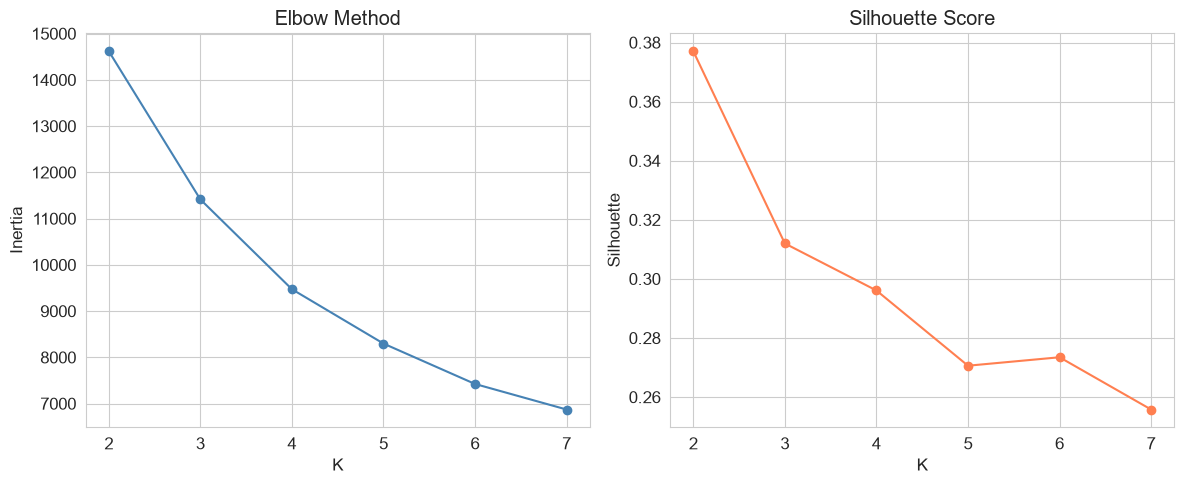

In [42]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

cols = ['recency', 'frequency', 'monetary', 'avg_order_value', 'total_items', 'customer_lifetime_days']
X = np.log1p(rfm[cols].clip(lower=0))
X_scaled = StandardScaler().fit_transform(X)

inertias, silhouettes = [], []
K_range = range(2, 8)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(K_range, inertias, 'o-', color='steelblue')
axes[0].set_title('Elbow Method')
axes[0].set_xlabel('K')
axes[0].set_ylabel('Inertia')
axes[1].plot(K_range, silhouettes, 'o-', color='coral')
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('K')
axes[1].set_ylabel('Silhouette')
plt.tight_layout()
plt.show()

Best K=2; silhouette=0.377


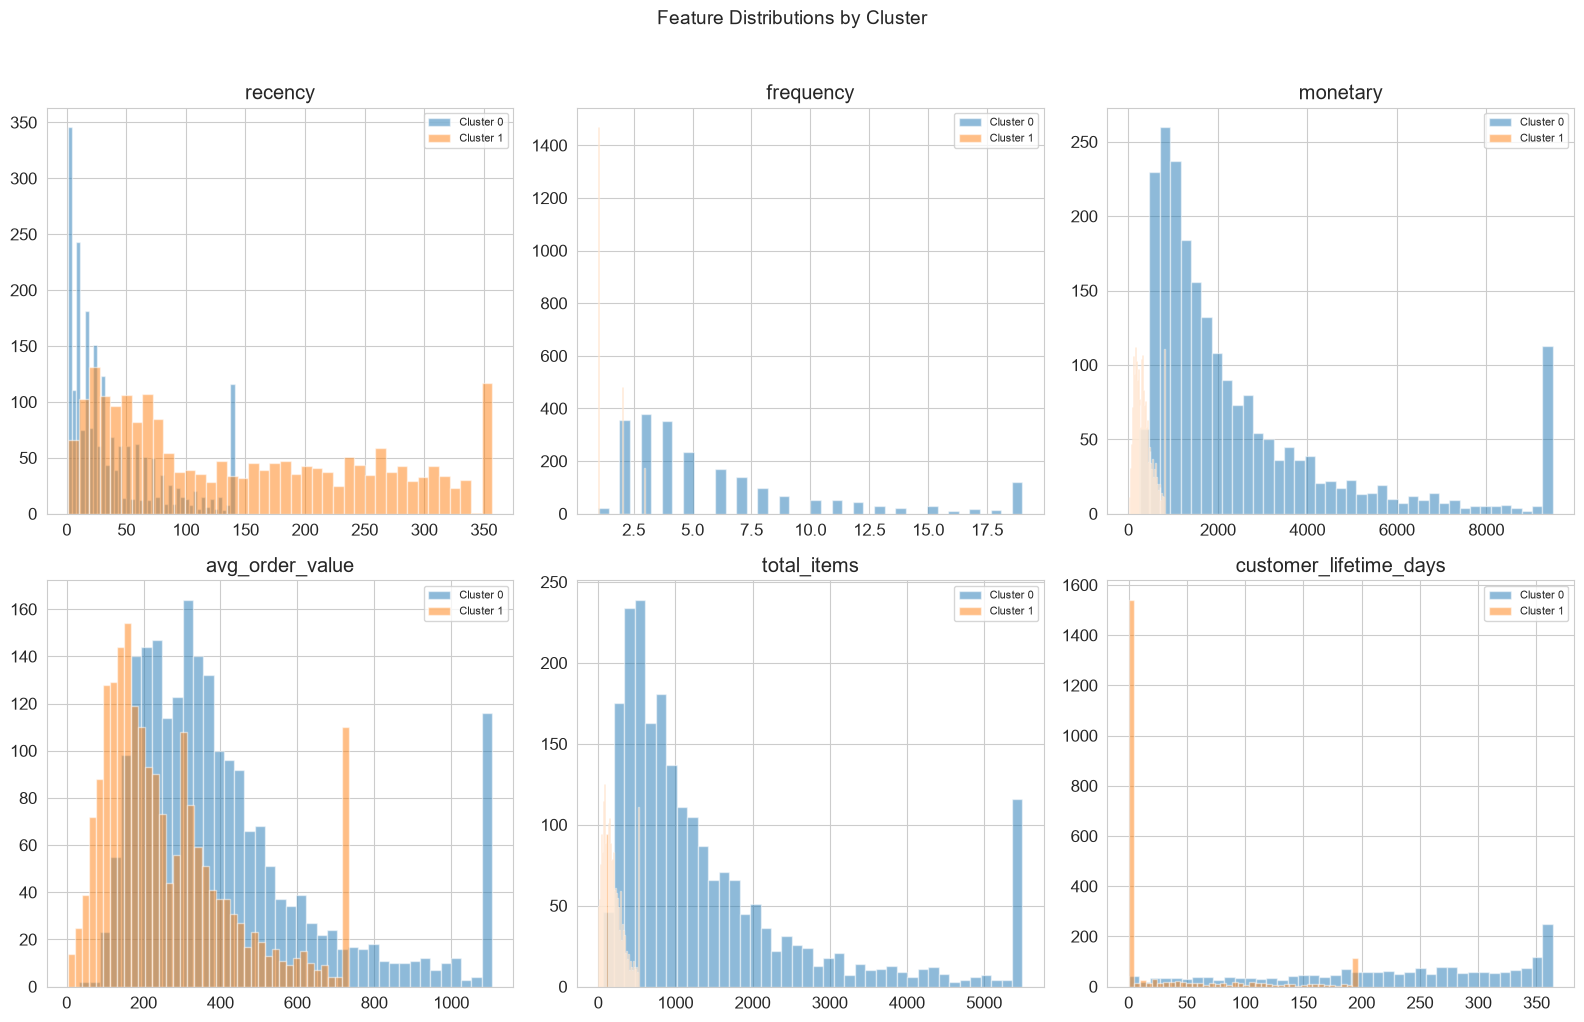

In [43]:
from src.modeling import kmeans_cluster
clustered = kmeans_cluster(rfm)

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
for i, col in enumerate(cols):
    ax = axes[i // 3, i % 3]
    for cl in sorted(clustered['Cluster'].unique()):
        data = clustered[clustered['Cluster'] == cl][col]
        ax.hist(data.clip(upper=data.quantile(0.95)), bins=40, alpha=0.5, label=f'Cluster {cl}')
    ax.set_title(col)
    ax.legend(fontsize=8)
plt.suptitle('Feature Distributions by Cluster', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [44]:
cluster_profile = clustered.groupby('Cluster').agg(
    Customers=('CustomerID', 'count'),
    Avg_Recency=('recency', 'mean'),
    Avg_Frequency=('frequency', 'mean'),
    Avg_Monetary=('monetary', 'mean'),
    Avg_AOV=('avg_order_value', 'mean'),
    Total_Revenue=('monetary', 'sum')
).round(2)
cluster_profile['Pct_Customers'] = (cluster_profile['Customers'] / cluster_profile['Customers'].sum() * 100).round(1)
cluster_profile['Pct_Revenue'] = (cluster_profile['Total_Revenue'] / cluster_profile['Total_Revenue'].sum() * 100).round(1)
cluster_profile

,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary,Avg_AOV,Total_Revenue,Pct_Customers,Pct_Revenue
Cluster,,,,,,,,
0,2213,40.53,7.01,3675.95,547.82,8134866.33,51.0,91.5
1,2125,146.69,1.42,354.04,282.08,752342.56,49.0,8.5


## 6. Cohort Retention Analysis

Tracking how many customers from each monthly cohort return over subsequent months.

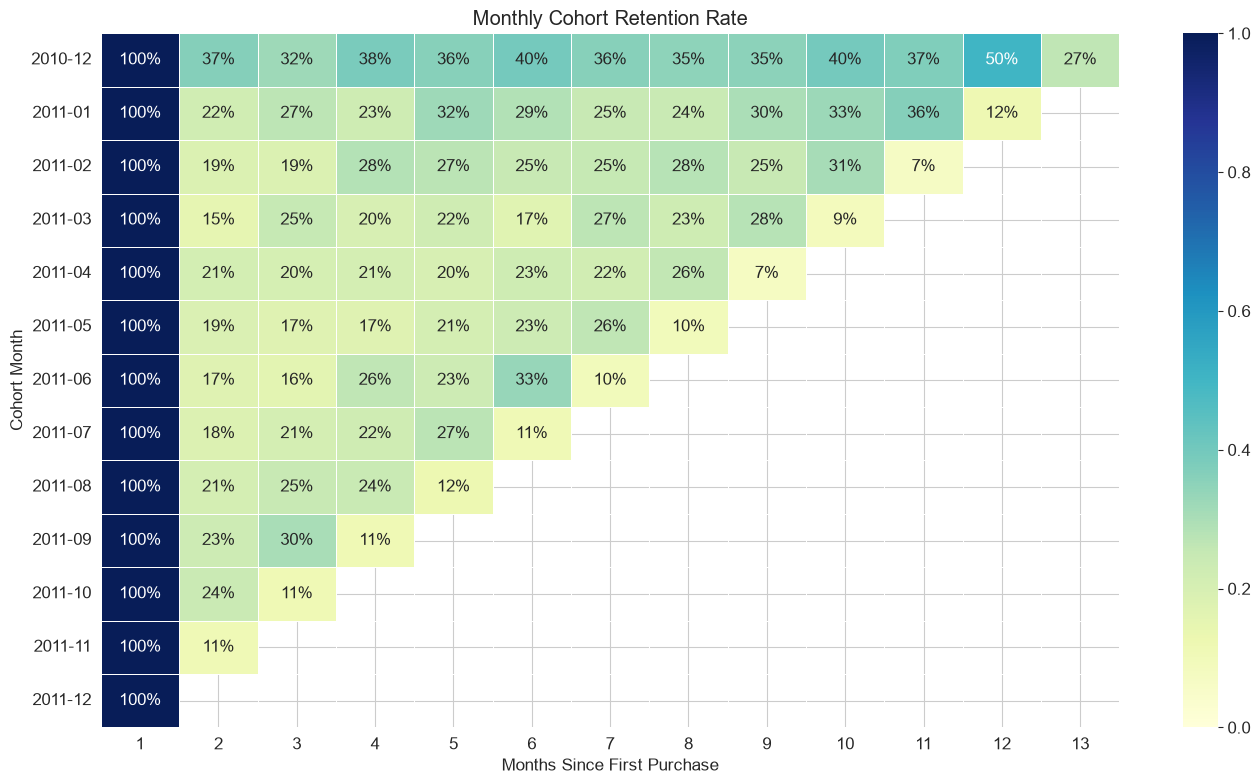

In [49]:
cohort = pd.read_csv(ROOT/'data'/'processed'/'cohort_retention.csv')
cohort_pivot = cohort.pivot(index='cohort_month', columns='cohort_index', values='retention')

fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(cohort_pivot, annot=True, fmt='.0%', cmap='YlGnBu', ax=ax,
            linewidths=0.5, vmin=0, vmax=1)
ax.set_title('Monthly Cohort Retention Rate')
ax.set_xlabel('Months Since First Purchase')
ax.set_ylabel('Cohort Month')
plt.tight_layout()
plt.show()

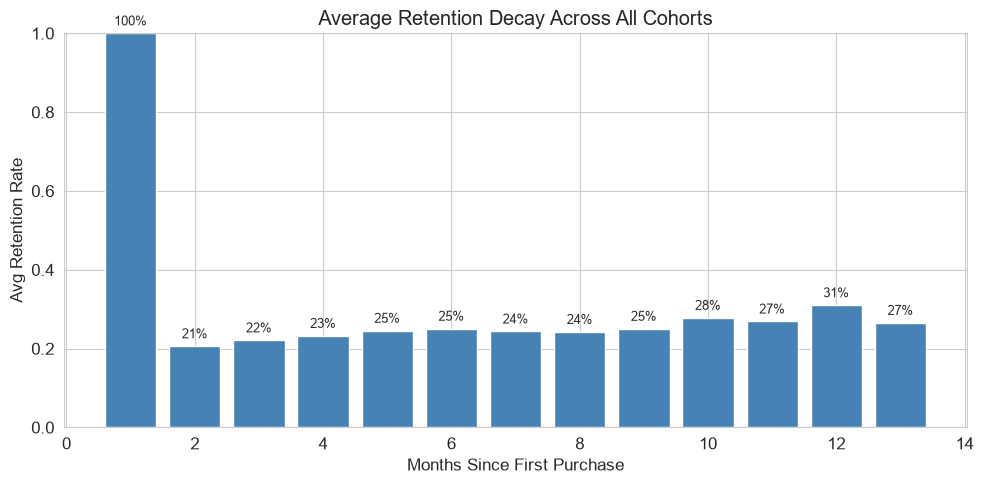

In [50]:
# Average retention by month index
avg_retention = cohort.groupby('cohort_index')['retention'].mean()
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(avg_retention.index, avg_retention.values, color='steelblue', edgecolor='white')
ax.set_xlabel('Months Since First Purchase')
ax.set_ylabel('Avg Retention Rate')
ax.set_title('Average Retention Decay Across All Cohorts')
ax.set_ylim(0, 1)
for i, v in enumerate(avg_retention.values):
    ax.text(i + 1, v + 0.02, f'{v:.0%}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

## 7. Temporal Churn Prediction

We define churn as zero purchases in the prediction window (last 25% of dates). Features are built from the observation window (first 75%) to prevent temporal data leakage.

Two models are compared: Logistic Regression (interpretable baseline) and Random Forest (non-linear).

In [53]:
churn_df = pd.read_csv(ROOT/'data'/'processed'/'churn_dataset.csv')
fi = pd.read_csv(ROOT/'data'/'processed'/'feature_importance.csv')
print(f'Churn dataset: {churn_df.shape}')
print(f'Churn rate: {churn_df["churn"].mean():.1%}')
churn_df.head()

Churn dataset: (3385, 12)
Churn rate: 43.2%


,CustomerID,last_purchase,first_purchase,frequency,monetary,total_items,avg_order_value,recency,customer_lifetime_days,avg_days_between_orders,future_orders,churn
0,12346.0,2011-01-18 10:01:00,2011-01-18 10:01:00,1,77183.60,74215,77183.600000,236,0,0.00,0.0,1
1,12347.0,2011-08-02 08:48:00,2010-12-07 14:57:00,5,2790.86,1590,558.172000,40,237,58.75,2.0,0
2,12348.0,2011-04-05 10:47:00,2010-12-16 19:09:00,3,1487.24,2124,495.746667,159,109,54.50,1.0,0
3,12350.0,2011-02-02 16:01:00,2011-02-02 16:01:00,1,334.40,197,334.400000,221,0,0.00,0.0,1
4,12352.0,2011-03-22 16:08:00,2011-02-16 12:33:00,5,1561.81,254,312.362000,173,34,8.50,3.0,0


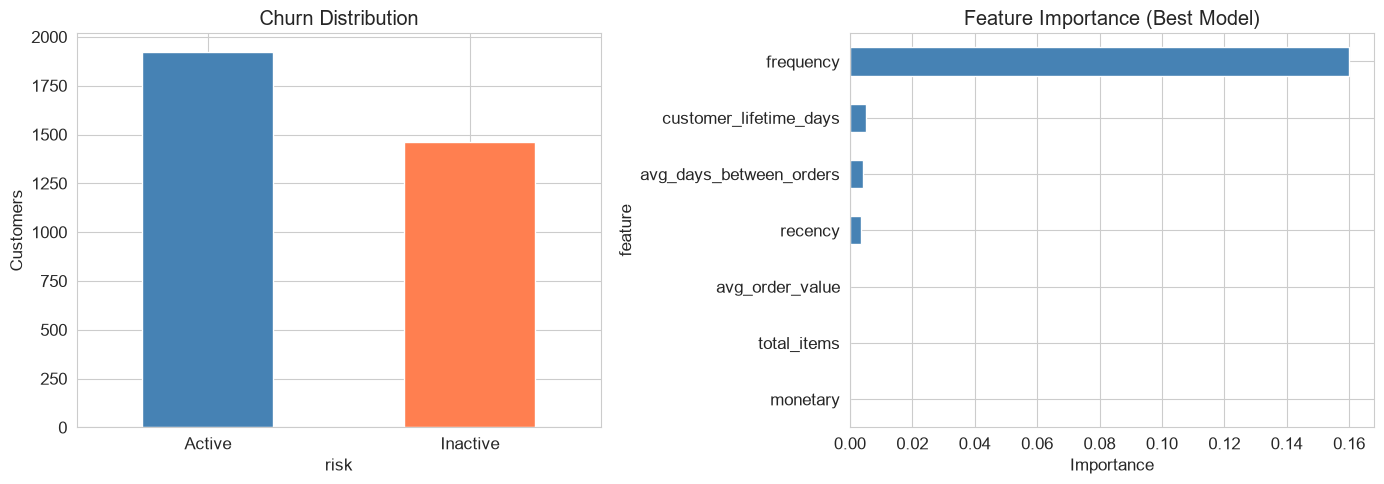

In [54]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

churn_df['risk'] = churn_df['churn'].map({0: 'Active', 1: 'Inactive'})
risk_counts = churn_df['risk'].value_counts()
risk_counts.plot(kind='bar', ax=axes[0], color=['steelblue', 'coral'], edgecolor='white')
axes[0].set_title('Churn Distribution')
axes[0].set_ylabel('Customers')
axes[0].tick_params(axis='x', rotation=0)

# Feature importance
fi_sorted = fi.sort_values('importance', ascending=True)
fi_sorted.plot(kind='barh', x='feature', y='importance', ax=axes[1], color='steelblue', legend=False)
axes[1].set_title('Feature Importance (Best Model)')
axes[1].set_xlabel('Importance')

plt.tight_layout()
plt.show()

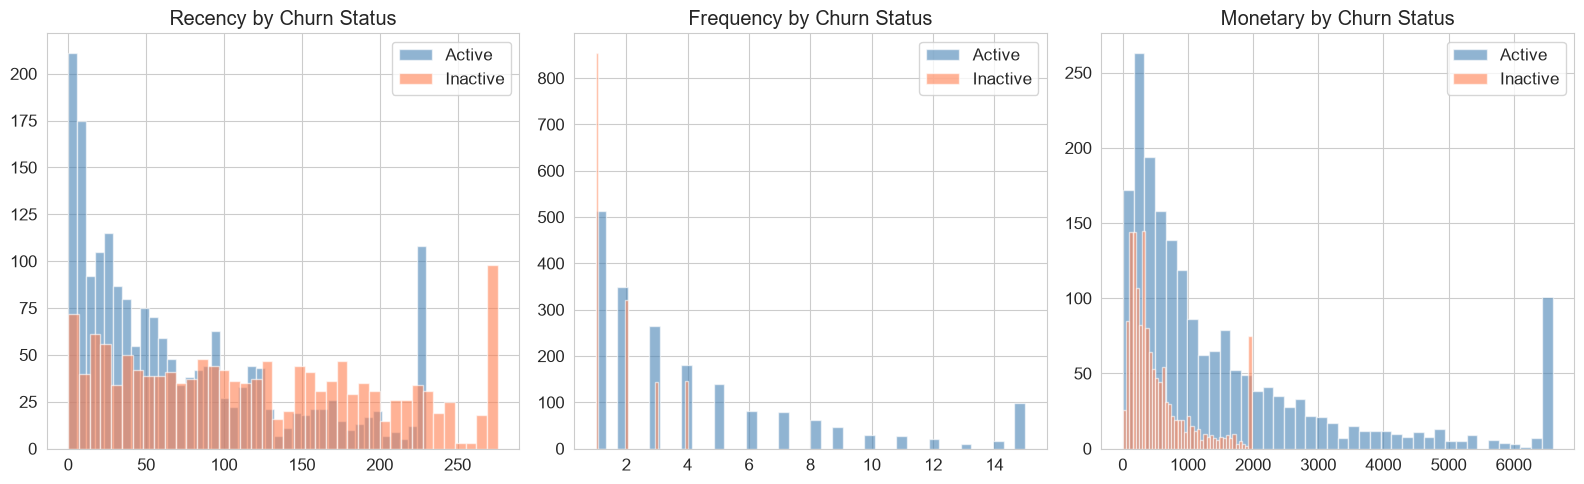

In [55]:
# Compare churned vs active customers
active = churn_df[churn_df['churn'] == 0]
inactive = churn_df[churn_df['churn'] == 1]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for i, col in enumerate(['recency', 'frequency', 'monetary']):
    ax = axes[i]
    ax.hist(active[col].clip(upper=active[col].quantile(0.95)), bins=40, alpha=0.6, label='Active', color='steelblue')
    ax.hist(inactive[col].clip(upper=inactive[col].quantile(0.95)), bins=40, alpha=0.6, label='Inactive', color='coral')
    ax.set_title(f'{col.title()} by Churn Status')
    ax.legend()
plt.tight_layout()
plt.show()

## 8. Business Recommendations

Based on the analysis, here are actionable recommendations organized by customer segment and business priority.

### Revenue Intelligence
- **Pareto concentration**: The top ~20% of customers generate 80% of revenue. Protect this base with dedicated account management and loyalty programs.
- **UK dominance**: The UK accounts for the vast majority of revenue. International expansion in Germany, France, and EIRE represents growth opportunity.

### Segment-Specific Actions

| Segment | Strategy |
|---------|----------|
| **Champions** | Reward loyalty; early access to new products; referral programs |
| **Loyal Customers** | Upsell/cross-sell; membership tiers; personalized recommendations |
| **Potential Loyalists** | Onboarding sequences; first-purchase follow-ups; volume discounts |
| **Low Value** | Re-engagement campaigns; limited-time offers; automated email sequences |
| **At Risk/Lost** | Win-back campaigns with significant incentives; exit surveys; sunset if unresponsive |

### Churn Prevention
- **Top predictors**: Recency, frequency, and customer lifetime are the strongest signals of inactivity.
- **Early warning**: Customers with declining order frequency over 2-3 months should trigger automated outreach.
- **ROI optimization**: High-value customers at risk warrant human intervention; low-value at-risk customers should receive lower-cost automated campaigns.

### Retention Tactics
- **Cohort analysis** shows sharp first-month drop-off. The critical window is the first 30 days post-acquisition.
- Invest in post-purchase engagement: thank-you emails, product tutorials, reorder reminders.
- **Subscription/loyalty programs** could flatten the retention decay curve.

### Data-Driven Next Steps
1. Build a real-time scoring API that scores customers daily on churn risk
2. A/B test retention interventions on high-risk segments
3. Expand features with product category preferences and seasonal patterns
4. Implement a customer lifetime value (CLV) model for acquisition budgeting